In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [5]:
df_fe = pd.read_csv("../../data/respuestas_fede.csv")
print(df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)
# genero
cant_marmol_masc = len(marmol[marmol['genero']=="Masculino"])
cant_marmol_fem = len(marmol[marmol['genero']=="Femenino"])
cant_mantovani_masc = len(mantovani[mantovani['genero']=="Masculino"])
cant_mantovani_fem = len(mantovani[mantovani['genero']=="Femenino"])
# grados
cant_marmol_quinto = len(marmol[marmol['grado']=="Quinto"])
cant_marmol_sexto = len(marmol[marmol['grado']=="Sexto"])
cant_mantovani_cuarto = len(mantovani[mantovani['grado']=="Cuarto"])
cant_mantovani_quinto = len(mantovani[mantovani['grado']=="Quinto"])
cant_mantovani_sexto = len(mantovani[mantovani['grado']=="Sexto"])

(369, 22)


## ¿Dónde se almacenan los videos que están en YouTube? 

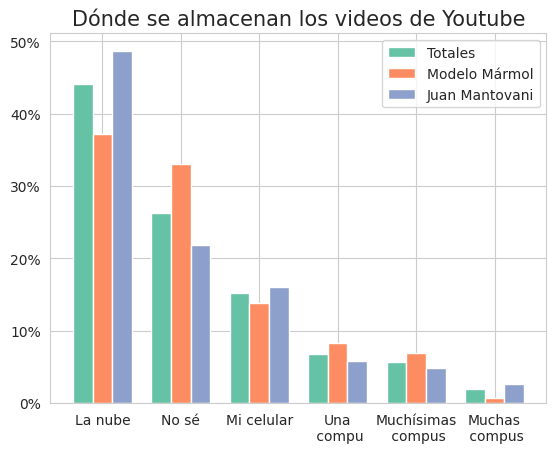

In [45]:
# ¿Dónde se almacenan los videos que están en YouTube? 
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

labels = ["La nube", "No sé", "Mi celular", "Una\n compu", "Muchísimas\n compus", "Muchas\n compus"]

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube", fontsize=15)
plt.xticks([x + bar_width for x in br1], labels=labels)
plt.legend()
plt.savefig('donde_youtube.png')

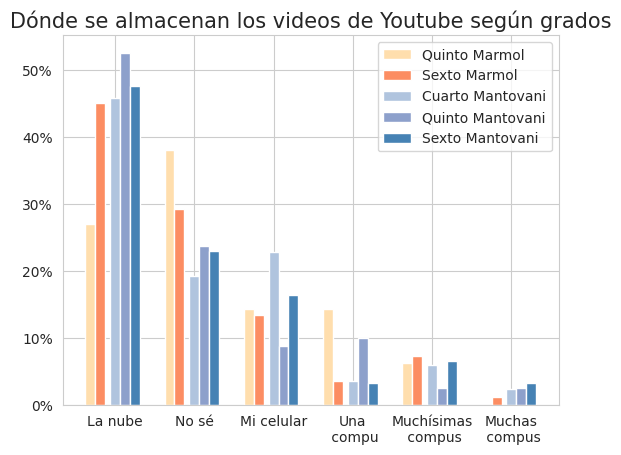

In [75]:
# ¿Dónde se almacenan los videos que están en YouTube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

result = result.reindex(["En la nube", "No sé", "En mi celular", "En una computadora",
                         "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)",
                         "En muchas computadoras (tantas que podrían llenar una casa)"])

labels = ["La nube", "No sé", "Mi celular", "Una\n compu", "Muchísimas\n compus", "Muchas\n compus"]

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según grados", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], labels=labels)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_grados.png')


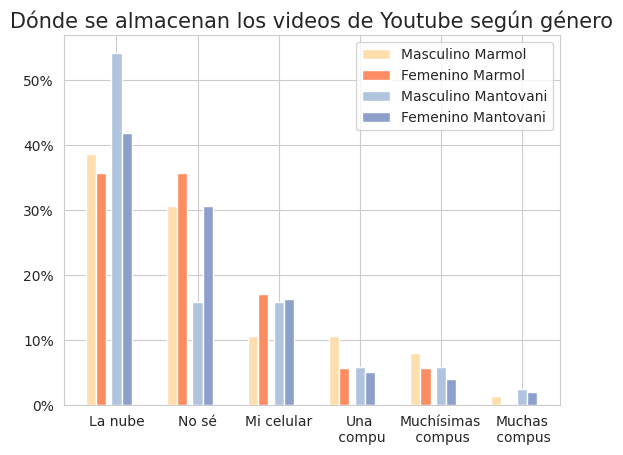

In [84]:
# ¿Dónde se almacenan los videos que están en YouTube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

result = result.reindex(["En la nube", "No sé", "En mi celular", "En una computadora", 
                         "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)",
                         "En muchas computadoras (tantas que podrían llenar una casa)"])

labels = ["La nube", "No sé", "Mi celular", "Una\n compu", "Muchísimas\n compus", "Muchas\n compus"]

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según género", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], labels=labels)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_genero.png')


# Preguntas Misc
* ¿Marcar con un color distinto las respuestas missc? - No, por ahora
* respuestas totales vs colegios
* respuetas por grados
* respuestas por genero

## ¿Quién tiene acceso a las fotos que tengo guardadas en mi celular?

## Cuando le mando a una amiga una foto por WhatsApp..

## Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer?

## Sofi está en la calle sin Wi-Fi y le quiere mandar un mensaje de WhatsApp a Santi.  ¿Cuál de las cinco imágenes representa mejor la manera en la que el mensaje viaja?

## Si me llega un mensaje por WhatsApp con un link para descargar una aplicación, ¿cuál de las siguientes opciones creés que es la correcta?

# Seccion nube
## En informática, ¿qué es la nube?

## conteo de alumnos en esta nueva seccion
## comparativa entre colegios y grados

## De las siguientes afirmaciones sobre la nube, marcá la o las que creas correctas (podés elegir más de una opción):

## Si cada círculo representa las cosas que podemos hacer con Internet y la nube, ¿cómo creés que se comportan?

# Wikipedia

## ¿Conocés o alguna vez usaste Wikipedia?

## conteo

## Si tengo que hacer un trabajo para la escuela y después de buscar en Wikipedia encuentro un artículo que habla del tema, ¿cuál de las siguientes opciones creés que es la correcta?

---- Hasta la semana que viene? - HAcer  los graficos genericos, despues revisitamos
